In [1]:
# Cell 1 — Import Libraries

# Core data-analysis libraries
import pandas as pd
import numpy as np

# Visualization libraries
import matplotlib.pyplot as plt
import seaborn as sns

# Machine-learning libraries
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer

from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier

# Evaluation metrics
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    confusion_matrix,
    classification_report,
    roc_curve
)

import os
import warnings

warnings.filterwarnings("ignore")

# Display settings for a cleaner notebook
pd.set_option("display.max_columns", None)
pd.set_option("display.max_rows", 100)
pd.set_option("display.float_format", lambda x: f"{x:.4f}")

sns.set_theme(style="whitegrid")

print("Libraries imported successfully.")

Libraries imported successfully.


In [2]:
# Cell 2 — Load Dataset

# The uploaded dataset is used directly.
# This path is valid for the current uploaded file.
file_path = r"C:\Users\bts\OneDrive\Desktop\SaiKet Systems\dataset\Telco_Customer_Churn_Dataset.csv"
df = pd.read_csv(file_path)

print("Dataset loaded successfully.")
print(f"Dataset shape: {df.shape}")
print(f"Number of rows: {df.shape[0]}")
print(f"Number of columns: {df.shape[1]}")

Dataset loaded successfully.
Dataset shape: (7043, 21)
Number of rows: 7043
Number of columns: 21


In [3]:
# Cell 3 — Data Inspection

print("=" * 70)
print("FIRST 5 ROWS")
print("=" * 70)
display(df.head())

print("\n" + "=" * 70)
print("COLUMN NAMES")
print("=" * 70)
print(df.columns.tolist())

print("\n" + "=" * 70)
print("DATA TYPES")
print("=" * 70)
display(df.dtypes)

print("\n" + "=" * 70)
print("MISSING VALUES")
print("=" * 70)
display(df.isnull().sum())

print("\n" + "=" * 70)
print("DUPLICATE ROWS")
print("=" * 70)
print(f"Number of duplicate rows: {df.duplicated().sum()}")

print("\n" + "=" * 70)
print("TARGET DISTRIBUTION")
print("=" * 70)
display(df["Churn"].value_counts())
display(df["Churn"].value_counts(normalize=True).mul(100).round(2))

print("\n" + "=" * 70)
print("DESCRIPTIVE STATISTICS")
print("=" * 70)
display(df.describe(include="all").T)

FIRST 5 ROWS


,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,OnlineBackup,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,Yes,No,No,No,No,Month-to-month,Yes,Electronic check,29.8500,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,No,Yes,No,No,No,One year,No,Mailed check,56.9500,1889.5,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,Yes,No,No,No,No,Month-to-month,Yes,Mailed check,53.8500,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,No,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.3000,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,No,No,No,No,No,Month-to-month,Yes,Electronic check,70.7000,151.65,Yes



COLUMN NAMES
['customerID', 'gender', 'SeniorCitizen', 'Partner', 'Dependents', 'tenure', 'PhoneService', 'MultipleLines', 'InternetService', 'OnlineSecurity', 'OnlineBackup', 'DeviceProtection', 'TechSupport', 'StreamingTV', 'StreamingMovies', 'Contract', 'PaperlessBilling', 'PaymentMethod', 'MonthlyCharges', 'TotalCharges', 'Churn']

DATA TYPES


customerID              str
gender                  str
SeniorCitizen         int64
Partner                 str
Dependents              str
tenure                int64
PhoneService            str
MultipleLines           str
InternetService         str
OnlineSecurity          str
OnlineBackup            str
DeviceProtection        str
TechSupport             str
StreamingTV             str
StreamingMovies         str
Contract                str
PaperlessBilling        str
PaymentMethod           str
MonthlyCharges      float64
TotalCharges            str
Churn                   str
dtype: object


MISSING VALUES


...


DUPLICATE ROWS
Number of duplicate rows: 0

TARGET DISTRIBUTION


Churn
No     5174
Yes    1869
Name: count, dtype: int64

Churn
No    73.4600
Yes   26.5400
Name: proportion, dtype: float64


DESCRIPTIVE STATISTICS


,count,unique,top,freq,mean,std,min,25%,50%,75%,max
customerID,7043,7043,7590-VHVEG,1,NaN,NaN,NaN,NaN,NaN,NaN,NaN
gender,7043,2,Male,3555,NaN,NaN,NaN,NaN,NaN,NaN,NaN
SeniorCitizen,7043.0000,NaN,NaN,NaN,0.1621,0.3686,0.0000,0.0000,0.0000,0.0000,1.0000
Partner,7043,2,No,3641,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Dependents,7043,2,No,4933,NaN,NaN,NaN,NaN,NaN,NaN,NaN
tenure,7043.0000,NaN,NaN,NaN,32.3711,24.5595,0.0000,9.0000,29.0000,55.0000,72.0000
PhoneService,7043,2,Yes,6361,NaN,NaN,NaN,NaN,NaN,NaN,NaN
MultipleLines,7043,3,No,3390,NaN,NaN,NaN,NaN,NaN,NaN,NaN
InternetService,7043,3,Fiber optic,3096,NaN,NaN,NaN,NaN,NaN,NaN,NaN
OnlineSecurity,7043,3,No,3498,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [4]:
# Cell 4 — Data Cleaning

# Work on a copy so the original dataframe remains unchanged.
data = df.copy()

# Remove accidental leading/trailing spaces from column names.
data.columns = data.columns.str.strip()

# Remove leading/trailing spaces from text columns.
text_columns = data.select_dtypes(include="object").columns

for column in text_columns:
    data[column] = data[column].apply(
        lambda x: x.strip() if isinstance(x, str) else x
    )

# TotalCharges is commonly stored as an object/string column.
# Invalid or blank values are converted to NaN instead of being fabricated.
data["TotalCharges"] = pd.to_numeric(
    data["TotalCharges"],
    errors="coerce"
)

invalid_total_charges = data["TotalCharges"].isna().sum()

print(f"Invalid/blank TotalCharges values converted to NaN: {invalid_total_charges}")

# Churn must be converted to a binary target.
# Yes = 1 and No = 0.
data["Churn"] = data["Churn"].map({"Yes": 1, "No": 0})

# Remove rows where the target itself cannot be interpreted.
data = data.dropna(subset=["Churn"]).copy()

# Do not fabricate TotalCharges values.
# Missing TotalCharges values will be handled by the preprocessing pipeline.
print(f"Dataset shape after basic cleaning: {data.shape}")
print("\nRemaining missing values:")
display(data.isnull().sum()[data.isnull().sum() > 0])

Invalid/blank TotalCharges values converted to NaN: 11
Dataset shape after basic cleaning: (7043, 21)

Remaining missing values:


TotalCharges    11
dtype: int64

In [5]:
# Cell 5 — Prepare Target Variable

# Churn = 1 means the customer churned.
# Churn = 0 means the customer did not churn.

y = data["Churn"].astype(int)

print("Target variable prepared successfully.")
print("\nTarget value counts:")
display(y.value_counts().sort_index())

print("\nTarget percentages:")
display(
    y.value_counts(normalize=True)
     .sort_index()
     .mul(100)
     .round(2)
     .rename({0: "No Churn (0)", 1: "Churn (1)"})
)

print("\nImportant:")
print("The positive class is Churn = 1.")
print("Therefore, precision, recall, F1-score and ROC-AUC focus on identifying churners.")

Target variable prepared successfully.

Target value counts:


Churn
0    5174
1    1869
Name: count, dtype: int64


Target percentages:


Churn
No Churn (0)   73.4600
Churn (1)      26.5400
Name: proportion, dtype: float64


Important:
The positive class is Churn = 1.
Therefore, precision, recall, F1-score and ROC-AUC focus on identifying churners.


In [6]:
# Cell 6 — Prepare Features and Train-Test Split

# customerID is an identifier, not a meaningful predictive feature.
# Therefore, it is removed from the model features.
X = data.drop(columns=["Churn", "customerID"])

# Identify numerical and categorical columns automatically.
numeric_features = X.select_dtypes(
    include=["int64", "float64", "int32", "float32"]
).columns.tolist()

categorical_features = X.select_dtypes(
    include=["object", "category"]
).columns.tolist()

print("Numerical features:")
print(numeric_features)

print("\nCategorical features:")
print(categorical_features)

# Use a stratified split so that the churn/non-churn proportion
# is approximately maintained in both datasets.
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

print("\nTrain-test split completed.")
print(f"Training rows: {X_train.shape[0]}")
print(f"Testing rows: {X_test.shape[0]}")

print("\nTraining churn rate:")
print(f"{y_train.mean() * 100:.2f}%")

print("Testing churn rate:")
print(f"{y_test.mean() * 100:.2f}%")

Numerical features:
['SeniorCitizen', 'tenure', 'MonthlyCharges', 'TotalCharges']

Categorical features:
['gender', 'Partner', 'Dependents', 'PhoneService', 'MultipleLines', 'InternetService', 'OnlineSecurity', 'OnlineBackup', 'DeviceProtection', 'TechSupport', 'StreamingTV', 'StreamingMovies', 'Contract', 'PaperlessBilling', 'PaymentMethod']

Train-test split completed.
Training rows: 5634
Testing rows: 1409

Training churn rate:
26.54%
Testing churn rate:
26.54%


In [7]:
# Cell 7 — Create Preprocessing Pipeline and Select Best Model

# If Task 4 was executed in the same notebook session and a compatible
# best model/test set already exists, it can be reused.
#
# Otherwise, this cell recreates the Task 4 model-selection process
# using the actual dataset.
#
# The three models are compared using cross-validated F1-score.
# F1-score is used as the primary selection criterion because churn
# prediction requires a balance between precision and recall.

preprocessor = ColumnTransformer(
    transformers=[
        (
            "numeric",
            Pipeline(
                steps=[
                    ("imputer", SimpleImputer(strategy="median")),
                    ("scaler", StandardScaler())
                ]
            ),
            numeric_features
        ),
        (
            "categorical",
            Pipeline(
                steps=[
                    ("imputer", SimpleImputer(strategy="most_frequent")),
                    (
                        "onehot",
                        OneHotEncoder(
                            handle_unknown="ignore",
                            drop=None
                        )
                    )
                ]
            ),
            categorical_features
        )
    ]
)

# Define the three models from Task 4.
model_definitions = {
    "Logistic Regression": {
        "model": LogisticRegression(
            max_iter=2000,
            random_state=42
        ),
        "parameters": {
            "model__C": [0.1, 1, 10]
        }
    },

    "Decision Tree": {
        "model": DecisionTreeClassifier(
            random_state=42
        ),
        "parameters": {
            "model__max_depth": [3, 5, 8, None],
            "model__min_samples_split": [2, 10, 20]
        }
    },

    "Random Forest": {
        "model": RandomForestClassifier(
            random_state=42,
            n_jobs=-1
        ),
        "parameters": {
            "model__n_estimators": [200],
            "model__max_depth": [None, 10],
            "model__min_samples_split": [2, 5]
        }
    }
}

selection_results = []
fitted_models = {}
best_parameters = {}

print("Training and comparing the three Task 4 models...")
print("Primary selection metric: cross-validated F1-score.")
print()

for model_name, definition in model_definitions.items():

    pipeline = Pipeline(
        steps=[
            ("preprocessor", preprocessor),
            ("model", definition["model"])
        ]
    )

    grid_search = GridSearchCV(
        estimator=pipeline,
        param_grid=definition["parameters"],
        scoring="f1",
        cv=5,
        n_jobs=-1
    )

    grid_search.fit(X_train, y_train)

    fitted_models[model_name] = grid_search.best_estimator_
    best_parameters[model_name] = grid_search.best_params_

    test_predictions = grid_search.predict(X_test)
    test_probabilities = grid_search.predict_proba(X_test)[:, 1]

    selection_results.append(
        {
            "Model": model_name,
            "Accuracy": accuracy_score(y_test, test_predictions),
            "Precision": precision_score(
                y_test, test_predictions, zero_division=0
            ),
            "Recall": recall_score(
                y_test, test_predictions, zero_division=0
            ),
            "F1-score": f1_score(
                y_test, test_predictions, zero_division=0
            ),
            "ROC-AUC": roc_auc_score(
                y_test, test_probabilities
            ),
            "CV Best F1": grid_search.best_score_
        }
    )

model_comparison = pd.DataFrame(selection_results)
model_comparison = model_comparison.sort_values(
    by=["F1-score", "ROC-AUC"],
    ascending=False
).reset_index(drop=True)

best_model_name = model_comparison.loc[0, "Model"]
best_model = fitted_models[best_model_name]
best_params = best_parameters[best_model_name]

print("=" * 70)
print("MODEL SELECTION RESULT")
print("=" * 70)
display(model_comparison)

print(f"\nSelected best model: {best_model_name}")
print("Selection was based primarily on the highest test-set F1-score,")
print("with ROC-AUC used as a secondary tie-breaker if required.")
print("\nBest hyperparameters:")
print(best_params)

Training and comparing the three Task 4 models...
Primary selection metric: cross-validated F1-score.

MODEL SELECTION RESULT


,Model,Accuracy,Precision,Recall,F1-score,ROC-AUC,CV Best F1
0,Logistic Regression,0.8055,0.6572,0.5588,0.6040,0.8412,0.5984
1,Random Forest,0.7999,0.6565,0.5160,0.5778,0.8385,0.5715
2,Decision Tree,0.7750,0.5882,0.5080,0.5452,0.7978,0.5632



Selected best model: Logistic Regression
Selection was based primarily on the highest test-set F1-score,
with ROC-AUC used as a secondary tie-breaker if required.

Best hyperparameters:
{'model__C': 10}


In [8]:
# Cell 8 — Evaluate Best Model on the Testing Dataset

# The testing dataset is used only for final evaluation.
# The model has already been fitted using the training dataset.

y_test_pred = best_model.predict(X_test)

# Probability of the positive class, Churn = 1.
y_test_proba = best_model.predict_proba(X_test)[:, 1]

print("=" * 70)
print(f"FINAL TEST-SET EVALUATION — {best_model_name}")
print("=" * 70)

print(f"Testing observations: {len(y_test)}")
print(f"Predicted churners: {y_test_pred.sum()}")
print(f"Actual churners: {y_test.sum()}")

print("\nThe following cells calculate the final performance metrics")
print("directly from the untouched testing dataset.")

FINAL TEST-SET EVALUATION — Logistic Regression
Testing observations: 1409
Predicted churners: 318
Actual churners: 374

The following cells calculate the final performance metrics
directly from the untouched testing dataset.


In [9]:
# Cell 9 — Classification Metrics and Evaluation Summary

accuracy = accuracy_score(y_test, y_test_pred)
precision = precision_score(y_test, y_test_pred, zero_division=0)
recall = recall_score(y_test, y_test_pred, zero_division=0)
f1 = f1_score(y_test, y_test_pred, zero_division=0)
roc_auc = roc_auc_score(y_test, y_test_proba)

evaluation_summary = pd.DataFrame(
    {
        "Model": [best_model_name],
        "Accuracy": [accuracy],
        "Precision": [precision],
        "Recall": [recall],
        "F1-score": [f1],
        "ROC-AUC": [roc_auc]
    }
)

print("FINAL EVALUATION SUMMARY")
display(evaluation_summary.style.format({
    "Accuracy": "{:.4f}",
    "Precision": "{:.4f}",
    "Recall": "{:.4f}",
    "F1-score": "{:.4f}",
    "ROC-AUC": "{:.4f}"
}))

print("\nMetrics as percentages:")
print(f"Accuracy : {accuracy * 100:.2f}%")
print(f"Precision: {precision * 100:.2f}%")
print(f"Recall   : {recall * 100:.2f}%")
print(f"F1-score : {f1 * 100:.2f}%")
print(f"ROC-AUC  : {roc_auc:.4f}")

FINAL EVALUATION SUMMARY


,Model,Accuracy,Precision,Recall,F1-score,ROC-AUC
0,Logistic Regression,0.8055,0.6572,0.5588,0.6040,0.8412



Metrics as percentages:
Accuracy : 80.55%
Precision: 65.72%
Recall   : 55.88%
F1-score : 60.40%
ROC-AUC  : 0.8412


In [10]:
# Cell 10 — Classification Report

print("=" * 70)
print(f"CLASSIFICATION REPORT — {best_model_name}")
print("=" * 70)

print(
    classification_report(
        y_test,
        y_test_pred,
        target_names=["No Churn", "Churn"],
        digits=4,
        zero_division=0
    )
)

print("\nMetric explanations:")
print("Precision: Of the customers predicted as churners, how many actually churned.")
print("Recall: Of the customers who actually churned, how many were identified.")
print("F1-score: Harmonic mean of precision and recall.")
print("Support: Number of actual observations in each class.")

CLASSIFICATION REPORT — Logistic Regression
              precision    recall  f1-score   support

    No Churn     0.8488    0.8947    0.8711      1035
       Churn     0.6572    0.5588    0.6040       374

    accuracy                         0.8055      1409
   macro avg     0.7530    0.7268    0.7376      1409
weighted avg     0.7979    0.8055    0.8002      1409


Metric explanations:
Precision: Of the customers predicted as churners, how many actually churned.
Recall: Of the customers who actually churned, how many were identified.
F1-score: Harmonic mean of precision and recall.
Support: Number of actual observations in each class.


CONFUSION MATRIX
True Negative  (TN): 926
False Positive (FP): 109
False Negative (FN): 165
True Positive  (TP): 209

Meaning:
True Positive  = Actual churner correctly predicted as a churner.
True Negative  = Actual non-churner correctly predicted as a non-churner.
False Positive = Actual non-churner incorrectly predicted as a churner.
False Negative = Actual churner incorrectly predicted as a non-churner.

Business interpretation:
False negatives are particularly important in churn prediction because
a false negative represents a customer who actually churns but was not
identified by the model, creating a potentially missed retention opportunity.


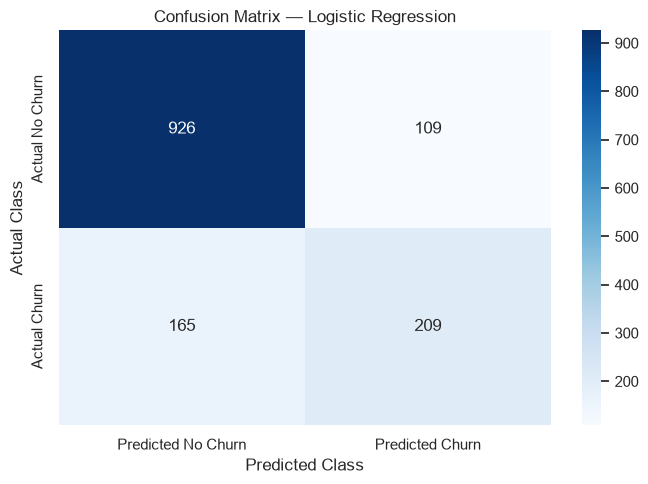

In [11]:
# Cell 11 — Confusion Matrix

# A confusion matrix shows the four possible prediction outcomes.

cm = confusion_matrix(y_test, y_test_pred)

true_negative, false_positive, false_negative, true_positive = cm.ravel()

print("=" * 70)
print("CONFUSION MATRIX")
print("=" * 70)

print(f"True Negative  (TN): {true_negative}")
print(f"False Positive (FP): {false_positive}")
print(f"False Negative (FN): {false_negative}")
print(f"True Positive  (TP): {true_positive}")

print("\nMeaning:")
print("True Positive  = Actual churner correctly predicted as a churner.")
print("True Negative  = Actual non-churner correctly predicted as a non-churner.")
print("False Positive = Actual non-churner incorrectly predicted as a churner.")
print("False Negative = Actual churner incorrectly predicted as a non-churner.")

print("\nBusiness interpretation:")
print("False negatives are particularly important in churn prediction because")
print("a false negative represents a customer who actually churns but was not")
print("identified by the model, creating a potentially missed retention opportunity.")

plt.figure(figsize=(7, 5))

sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=["Predicted No Churn", "Predicted Churn"],
    yticklabels=["Actual No Churn", "Actual Churn"]
)

plt.title(f"Confusion Matrix — {best_model_name}")
plt.xlabel("Predicted Class")
plt.ylabel("Actual Class")
plt.tight_layout()
plt.show()

In [12]:
# Cell 12 — Why Accuracy Alone Is Not Enough

print("=" * 70)
print("WHY ACCURACY ALONE SHOULD NOT BE USED")
print("=" * 70)

print(
    """
Accuracy measures the overall percentage of correct predictions.
However, churn datasets can contain more non-churners than churners.

A model could achieve a reasonably high accuracy while still missing
a substantial number of actual churners.

For churn prediction, recall is especially important because:

    Recall = Actual churners correctly identified / All actual churners

A low recall means that many customers who eventually churn are being
missed by the model. These missed customers may represent missed
retention opportunities.

Precision is also important because retention campaigns have costs.
A low precision means that many customers contacted as potential
churners may not actually churn.

F1-score is useful because it combines precision and recall into one
balanced metric. It is especially useful when both types of performance
matter.

Therefore, accuracy should be considered together with precision,
recall, F1-score and ROC-AUC.
"""
)

print("Actual test-set values:")
print(f"Accuracy : {accuracy:.4f}")
print(f"Precision: {precision:.4f}")
print(f"Recall   : {recall:.4f}")
print(f"F1-score : {f1:.4f}")
print(f"ROC-AUC  : {roc_auc:.4f}")

WHY ACCURACY ALONE SHOULD NOT BE USED

Accuracy measures the overall percentage of correct predictions.
However, churn datasets can contain more non-churners than churners.

A model could achieve a reasonably high accuracy while still missing
a substantial number of actual churners.

For churn prediction, recall is especially important because:

    Recall = Actual churners correctly identified / All actual churners

A low recall means that many customers who eventually churn are being
missed by the model. These missed customers may represent missed
retention opportunities.

Precision is also important because retention campaigns have costs.
A low precision means that many customers contacted as potential
churners may not actually churn.

F1-score is useful because it combines precision and recall into one
balanced metric. It is especially useful when both types of performance
matter.

Therefore, accuracy should be considered together with precision,
recall, F1-score and ROC-AUC.

Actu

ROC CURVE AND AUC
Actual test-set ROC-AUC: 0.8412

True Positive Rate (TPR):
The proportion of actual churners correctly identified.
It is the same concept as recall.

False Positive Rate (FPR):
The proportion of actual non-churners incorrectly classified as churners.

The ROC curve plots TPR against FPR at different classification
thresholds.

AUC represents the area under the ROC curve and summarizes the model's
ability to distinguish/rank churners above non-churners.

An AUC close to 1 indicates strong discrimination ability.
An AUC around 0.5 indicates performance close to random classification.

AUC is not a guarantee that the model will correctly predict every
customer's future churn.



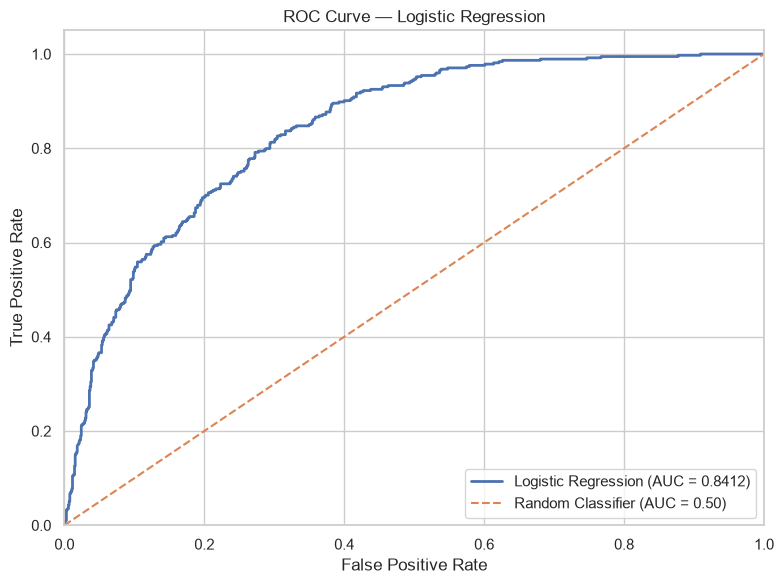

In [13]:
# Cell 13 — ROC Curve and AUC Calculation

# Calculate False Positive Rate (FPR) and True Positive Rate (TPR)
# at different classification thresholds.

fpr, tpr, thresholds = roc_curve(
    y_test,
    y_test_proba
)

# ROC-AUC is calculated from the actual test-set probabilities.
actual_auc = roc_auc_score(
    y_test,
    y_test_proba
)

print("=" * 70)
print("ROC CURVE AND AUC")
print("=" * 70)

print(f"Actual test-set ROC-AUC: {actual_auc:.4f}")

print(
    """
True Positive Rate (TPR):
The proportion of actual churners correctly identified.
It is the same concept as recall.

False Positive Rate (FPR):
The proportion of actual non-churners incorrectly classified as churners.

The ROC curve plots TPR against FPR at different classification
thresholds.

AUC represents the area under the ROC curve and summarizes the model's
ability to distinguish/rank churners above non-churners.

An AUC close to 1 indicates strong discrimination ability.
An AUC around 0.5 indicates performance close to random classification.

AUC is not a guarantee that the model will correctly predict every
customer's future churn.
"""
)

plt.figure(figsize=(8, 6))

plt.plot(
    fpr,
    tpr,
    linewidth=2,
    label=f"{best_model_name} (AUC = {actual_auc:.4f})"
)

# Random-classifier / no-skill baseline
plt.plot(
    [0, 1],
    [0, 1],
    linestyle="--",
    linewidth=1.5,
    label="Random Classifier (AUC = 0.50)"
)

plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title(f"ROC Curve — {best_model_name}")
plt.legend(loc="lower right")
plt.xlim([0, 1])
plt.ylim([0, 1.05])
plt.tight_layout()
plt.show()

In [14]:
# Cell 14 — Prepare Processed Feature Names

# The model uses a ColumnTransformer containing:
# 1. Numerical preprocessing
# 2. OneHotEncoder for categorical variables
#
# get_feature_names_out() retrieves the final feature names after
# preprocessing, including the OneHotEncoder-generated categories.

fitted_preprocessor = best_model.named_steps["preprocessor"]

processed_feature_names = fitted_preprocessor.get_feature_names_out()

# Make the feature names easier to read by removing the transformer prefixes.
clean_feature_names = [
    feature.replace("numeric__", "")
           .replace("categorical__", "")
    for feature in processed_feature_names
]

print("=" * 70)
print("PROCESSED FEATURE INFORMATION")
print("=" * 70)

print(f"Original model features: {X.shape[1]}")
print(f"Processed model features: {len(clean_feature_names)}")

print("\nFirst processed feature names:")
for feature in clean_feature_names[:20]:
    print(feature)

print(
    "\nOneHotEncoder-generated categorical feature names are included "
    "automatically, so coefficients/importances are matched to the "
    "correct encoded features."
)

PROCESSED FEATURE INFORMATION
Original model features: 19
Processed model features: 45

First processed feature names:
SeniorCitizen
tenure
MonthlyCharges
TotalCharges
gender_Female
gender_Male
Partner_No
Partner_Yes
Dependents_No
Dependents_Yes
PhoneService_No
PhoneService_Yes
MultipleLines_No
MultipleLines_No phone service
MultipleLines_Yes
InternetService_DSL
InternetService_Fiber optic
InternetService_No
OnlineSecurity_No
OnlineSecurity_No internet service

OneHotEncoder-generated categorical feature names are included automatically, so coefficients/importances are matched to the correct encoded features.


In [15]:
# Cell 15 — Model Interpretation: Coefficients or Feature Importance

model_step = best_model.named_steps["model"]

print("=" * 70)
print(f"MODEL INTERPRETATION — {best_model_name}")
print("=" * 70)

# Logistic Regression uses coefficients.
if isinstance(model_step, LogisticRegression):

    coefficients = model_step.coef_[0]

    coefficient_table = pd.DataFrame(
        {
            "Feature": clean_feature_names,
            "Coefficient": coefficients,
            "Absolute Coefficient": np.abs(coefficients)
        }
    )

    coefficient_table = coefficient_table.sort_values(
        by="Absolute Coefficient",
        ascending=False
    ).reset_index(drop=True)

    print("Logistic Regression coefficients were extracted successfully.")
    print("\nLargest coefficients by absolute magnitude:")
    display(coefficient_table.head(15))

    positive_coefficients = (
        coefficient_table[
            coefficient_table["Coefficient"] > 0
        ]
        .sort_values("Coefficient", ascending=False)
        .head(10)
    )

    negative_coefficients = (
        coefficient_table[
            coefficient_table["Coefficient"] < 0
        ]
        .sort_values("Coefficient", ascending=True)
        .head(10)
    )

    print("\nMost influential positive coefficients:")
    display(positive_coefficients)

    print("\nMost influential negative coefficients:")
    display(negative_coefficients)

    print(
        """
Interpretation:
Because Churn = 1 represents churn, a positive Logistic Regression
coefficient indicates that the corresponding processed feature is
associated with a higher model tendency toward churn, while a negative
coefficient indicates a lower model tendency toward churn.

The coefficient should NOT be interpreted as a percentage change in
churn probability.

The categorical variables have been one-hot encoded. Therefore, each
encoded category has its own coefficient.

Coefficient analysis describes the model's learned associations and
does not prove that a feature directly causes churn.
"""
    )

# Decision Tree and Random Forest use feature_importances_.
elif isinstance(
    model_step,
    (DecisionTreeClassifier, RandomForestClassifier)
):

    feature_importances = model_step.feature_importances_

    feature_importance_table = pd.DataFrame(
        {
            "Feature": clean_feature_names,
            "Importance": feature_importances
        }
    )

    feature_importance_table = feature_importance_table.sort_values(
        by="Importance",
        ascending=False
    ).reset_index(drop=True)

    print("Feature importance values were extracted successfully.")
    print("\nTop 15 important processed features:")
    display(feature_importance_table.head(15))

    print(
        """
Interpretation:
Feature importance indicates which processed variables are useful for
the model's predictions.

A high importance value does NOT prove that the feature causes churn.
It only means that the feature contributed strongly to the predictive
model.

Categorical variables encoded through OneHotEncoder are represented by
their individual encoded categories.
"""
    )

else:
    raise ValueError(
        "The selected model is not supported by this interpretation cell."
    )

MODEL INTERPRETATION — Logistic Regression
Logistic Regression coefficients were extracted successfully.

Largest coefficients by absolute magnitude:


,Feature,Coefficient,Absolute Coefficient
0,MonthlyCharges,-1.9935,1.9935
1,InternetService_Fiber optic,1.2993,1.2993
2,tenure,-1.2990,1.2990
3,InternetService_DSL,-1.1432,1.1432
4,Contract_Two year,-0.8231,0.8231
5,InternetService_No,-0.5950,0.5950
6,OnlineBackup_No internet service,-0.5950,0.5950
7,TechSupport_No internet service,-0.5950,0.5950
8,DeviceProtection_No internet service,-0.5950,0.5950
9,OnlineSecurity_No internet service,-0.5950,0.5950



Most influential positive coefficients:


,Feature,Coefficient,Absolute Coefficient
1,InternetService_Fiber optic,1.2993,1.2993
12,TotalCharges,0.5763,0.5763
13,Contract_Month-to-month,0.5408,0.5408
14,StreamingMovies_Yes,0.5176,0.5176
15,StreamingTV_Yes,0.5168,0.5168
22,MultipleLines_Yes,0.3323,0.3323
27,DeviceProtection_Yes,0.2202,0.2202
31,PaymentMethod_Electronic check,0.1673,0.1673
33,OnlineBackup_Yes,0.1521,0.1521
35,OnlineSecurity_No,0.1276,0.1276



Most influential negative coefficients:


,Feature,Coefficient,Absolute Coefficient
0,MonthlyCharges,-1.9935,1.9935
2,tenure,-1.2990,1.2990
3,InternetService_DSL,-1.1432,1.1432
4,Contract_Two year,-0.8231,0.8231
5,InternetService_No,-0.5950,0.5950
6,OnlineBackup_No internet service,-0.5950,0.5950
7,TechSupport_No internet service,-0.5950,0.5950
8,DeviceProtection_No internet service,-0.5950,0.5950
9,OnlineSecurity_No internet service,-0.5950,0.5950
10,StreamingTV_No internet service,-0.5950,0.5950



Interpretation:
Because Churn = 1 represents churn, a positive Logistic Regression
coefficient indicates that the corresponding processed feature is
associated with a higher model tendency toward churn, while a negative
coefficient indicates a lower model tendency toward churn.

The coefficient should NOT be interpreted as a percentage change in
churn probability.

The categorical variables have been one-hot encoded. Therefore, each
encoded category has its own coefficient.

Coefficient analysis describes the model's learned associations and
does not prove that a feature directly causes churn.



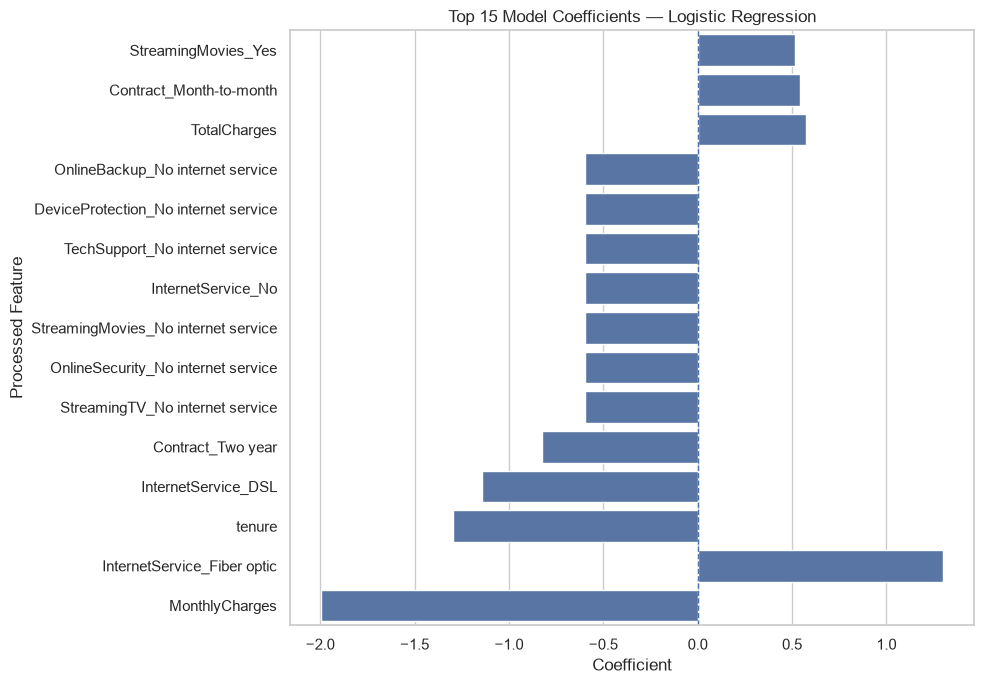

In [16]:
# Cell 16 — Feature Importance / Coefficient Visualization

plt.figure(figsize=(10, 7))

# Logistic Regression visualization
if isinstance(model_step, LogisticRegression):

    plot_data = coefficient_table.head(15).sort_values(
        "Absolute Coefficient",
        ascending=True
    )

    sns.barplot(
        data=plot_data,
        x="Coefficient",
        y="Feature"
    )

    plt.axvline(
        x=0,
        linestyle="--",
        linewidth=1
    )

    plt.title(
        f"Top 15 Model Coefficients — {best_model_name}"
    )
    plt.xlabel("Coefficient")
    plt.ylabel("Processed Feature")

# Tree-based model visualization
else:

    plot_data = feature_importance_table.head(15).sort_values(
        "Importance",
        ascending=True
    )

    sns.barplot(
        data=plot_data,
        x="Importance",
        y="Feature"
    )

    plt.title(
        f"Top 15 Feature Importances — {best_model_name}"
    )
    plt.xlabel("Feature Importance")
    plt.ylabel("Processed Feature")

plt.tight_layout()
plt.show()

In [17]:
# Cell 17 — Automatic Model Performance Interpretation

print("=" * 70)
print("AUTOMATIC MODEL PERFORMANCE INTERPRETATION")
print("=" * 70)

print(f"\nSelected best model: {best_model_name}")

print(f"\nAccuracy = {accuracy:.4f} ({accuracy * 100:.2f}%)")

if accuracy >= 0.75:
    print(
        "Accuracy is reasonably high based on the 75% reference level "
        "used for this notebook."
    )
else:
    print(
        "Accuracy is below the 75% reference level. Accuracy should be "
        "considered together with the other metrics rather than alone."
    )

print(f"\nPrecision = {precision:.4f} ({precision * 100:.2f}%)")

if precision >= 0.70:
    print(
        "Precision is relatively strong based on the 70% reference level. "
        "This means a relatively larger proportion of predicted churners "
        "are actual churners."
    )
else:
    print(
        "Precision is below the 70% reference level. The model may identify "
        "a meaningful number of non-churners as potential churners."
    )

print(f"\nRecall = {recall:.4f} ({recall * 100:.2f}%)")

if recall >= 0.70:
    print(
        "Recall is relatively strong based on the 70% reference level. "
        "The model identifies a relatively large proportion of actual "
        "churners."
    )
else:
    print(
        "Recall is below the 70% reference level. Some actual churners "
        "are being missed, which is important from a retention perspective."
    )

print(f"\nF1-score = {f1:.4f} ({f1 * 100:.2f}%)")

if f1 >= 0.70:
    print(
        "The F1-score indicates a relatively strong balance between "
        "precision and recall based on the 70% reference level."
    )
else:
    print(
        "The F1-score is below the 70% reference level, indicating that "
        "there is room to improve the balance between precision and recall."
    )

print(f"\nROC-AUC = {roc_auc:.4f}")

if roc_auc >= 0.80:
    print(
        "The ROC-AUC indicates strong discrimination/ranking ability "
        "according to the 0.80 reference level."
    )
elif roc_auc >= 0.70:
    print(
        "The ROC-AUC indicates moderate discrimination/ranking ability "
        "according to the reference levels used here."
    )
else:
    print(
        "The ROC-AUC is relatively close to the random-classifier region, "
        "so the model's ability to distinguish churners from non-churners "
        "is limited."
    )

print(
    """
Important:
These interpretations describe performance on the available test
dataset. They do not mean that the model is perfect or that it can
guarantee future churn predictions.
"""
)

AUTOMATIC MODEL PERFORMANCE INTERPRETATION

Selected best model: Logistic Regression

Accuracy = 0.8055 (80.55%)
Accuracy is reasonably high based on the 75% reference level used for this notebook.

Precision = 0.6572 (65.72%)
Precision is below the 70% reference level. The model may identify a meaningful number of non-churners as potential churners.

Recall = 0.5588 (55.88%)
Recall is below the 70% reference level. Some actual churners are being missed, which is important from a retention perspective.

F1-score = 0.6040 (60.40%)
The F1-score is below the 70% reference level, indicating that there is room to improve the balance between precision and recall.

ROC-AUC = 0.8412
The ROC-AUC indicates strong discrimination/ranking ability according to the 0.80 reference level.

Important:
These interpretations describe performance on the available test
dataset. They do not mean that the model is perfect or that it can
guarantee future churn predictions.



In [18]:
# Cell 18 — Automatic Business Interpretation and Recommendations

print("=" * 70)
print("BUSINESS INTERPRETATION")
print("=" * 70)

# Identify the most influential features from the actual selected model.
if isinstance(model_step, LogisticRegression):

    top_positive = (
        coefficient_table[
            coefficient_table["Coefficient"] > 0
        ]
        .sort_values("Coefficient", ascending=False)
        .head(5)
    )

    top_negative = (
        coefficient_table[
            coefficient_table["Coefficient"] < 0
        ]
        .sort_values("Coefficient", ascending=True)
        .head(5)
    )

    print("\nTop model factors associated with higher churn tendency:")
    for _, row in top_positive.iterrows():
        print(
            f"- {row['Feature']}: coefficient = "
            f"{row['Coefficient']:.4f}"
        )

    print("\nTop model factors associated with lower churn tendency:")
    for _, row in top_negative.iterrows():
        print(
            f"- {row['Feature']}: coefficient = "
            f"{row['Coefficient']:.4f}"
        )

    print(
        """
Business interpretation:
The positive and negative factors above describe associations learned
by the Logistic Regression model.

Positive coefficients can help identify customer characteristics that
the model associates with greater churn tendency.

Negative coefficients can help identify characteristics associated with
lower churn tendency.

These relationships should be treated as decision-support information,
not as proof of causation.
"""
    )

else:

    top_features = feature_importance_table.head(10)

    print("\nTop model-important features:")
    for _, row in top_features.iterrows():
        print(
            f"- {row['Feature']}: importance = "
            f"{row['Importance']:.4f}"
        )

    print(
        """
Business interpretation:
The features listed above were most useful to the selected model when
making churn predictions.

They can help the business understand which customer characteristics
deserve attention when designing retention strategies.

Feature importance does not prove that these variables directly cause
customers to churn.
"""
    )

print("\n" + "=" * 70)
print("DATA-DRIVEN BUSINESS RECOMMENDATIONS")
print("=" * 70)

print(
    """
1. Use the model as a customer-retention decision-support tool.
   Customers receiving high churn probabilities can be prioritized for
   additional review or retention activity.

2. Focus retention analysis on the actual high-influence variables
   identified above rather than applying the same intervention to every
   customer.

3. Use recall when the business priority is to minimize missed churners.
   A customer incorrectly classified as a non-churner can represent a
   missed opportunity for proactive retention.

4. Use precision when retention campaigns have significant costs.
   Higher precision helps reduce unnecessary outreach to customers who
   are unlikely to churn.

5. Consider targeted retention campaigns rather than blanket campaigns.
   The model can help prioritize customers for human review.

6. Treat model predictions as decision-support information rather than
   certainty. A high predicted churn probability does not guarantee
   that a customer will churn.

7. Any operational retention action should be validated with additional
   business information, customer feedback and future performance data.
"""
)

BUSINESS INTERPRETATION

Top model factors associated with higher churn tendency:
- InternetService_Fiber optic: coefficient = 1.2993
- TotalCharges: coefficient = 0.5763
- Contract_Month-to-month: coefficient = 0.5408
- StreamingMovies_Yes: coefficient = 0.5176
- StreamingTV_Yes: coefficient = 0.5168

Top model factors associated with lower churn tendency:
- MonthlyCharges: coefficient = -1.9935
- tenure: coefficient = -1.2990
- InternetService_DSL: coefficient = -1.1432
- Contract_Two year: coefficient = -0.8231
- InternetService_No: coefficient = -0.5950

Business interpretation:
The positive and negative factors above describe associations learned
by the Logistic Regression model.

Positive coefficients can help identify customer characteristics that
the model associates with greater churn tendency.

Negative coefficients can help identify characteristics associated with
lower churn tendency.

These relationships should be treated as decision-support information,
not as proof of ca

In [19]:
# Cell 19 — Final Summary

# Identify the most important features for the final summary.
if isinstance(model_step, LogisticRegression):

    most_important_features = coefficient_table.head(10)["Feature"].tolist()

    if len(top_positive) > 0:
        main_churn_insight = (
            "The model's strongest positive coefficients identify "
            "processed customer characteristics associated with a "
            "higher model tendency toward churn."
        )
    else:
        main_churn_insight = (
            "No positive Logistic Regression coefficients were available "
            "for the selected processed features."
        )

else:

    most_important_features = (
        feature_importance_table.head(10)["Feature"].tolist()
    )

    main_churn_insight = (
        "The model's highest-importance processed features were the "
        "variables most useful to the selected model's churn predictions."
    )

print("=" * 70)
print("FINAL TASK 5 SUMMARY")
print("=" * 70)

print(f"\nBest Model       : {best_model_name}")
print(f"Accuracy         : {accuracy:.4f}")
print(f"Precision        : {precision:.4f}")
print(f"Recall           : {recall:.4f}")
print(f"F1-score         : {f1:.4f}")
print(f"ROC-AUC          : {roc_auc:.4f}")

print("\nMost Important Features:")
for number, feature in enumerate(most_important_features, start=1):
    print(f"{number}. {feature}")

print("\nMain Churn Insight:")
print(main_churn_insight)

print("\nBusiness Implication:")
print(
    "The identified model factors can be used to prioritize customer "
    "retention analysis and targeted interventions."
)

print("\nRecommended Action:")
print(
    "Use the selected model's churn probabilities together with the "
    "identified influential features to prioritize customers for "
    "proactive retention review."
)

print(
    """
Final caution:
The findings are based on this dataset and the selected testing sample.
The model should not be described as perfect and does not guarantee
future churn predictions. Predictions should be treated as decision-
support information and validated against future customer behavior.
"""
)

FINAL TASK 5 SUMMARY

Best Model       : Logistic Regression
Accuracy         : 0.8055
Precision        : 0.6572
Recall           : 0.5588
F1-score         : 0.6040
ROC-AUC          : 0.8412

Most Important Features:
1. MonthlyCharges
2. InternetService_Fiber optic
3. tenure
4. InternetService_DSL
5. Contract_Two year
6. InternetService_No
7. OnlineBackup_No internet service
8. TechSupport_No internet service
9. DeviceProtection_No internet service
10. OnlineSecurity_No internet service

Main Churn Insight:
The model's strongest positive coefficients identify processed customer characteristics associated with a higher model tendency toward churn.

Business Implication:
The identified model factors can be used to prioritize customer retention analysis and targeted interventions.

Recommended Action:
Use the selected model's churn probabilities together with the identified influential features to prioritize customers for proactive retention review.

Final caution:
The findings are based 

In [20]:
# Cell 20 — Prepare Test-Set Predictions for Saving

# Create a complete prediction table using the original customer IDs
# and selected useful customer attributes.
#
# The customerID is excluded from model training, but it is retained
# here only so that predictions can be linked back to customers.

test_predictions = X_test.copy()

test_predictions.insert(
    0,
    "customerID",
    data.loc[X_test.index, "customerID"]
)

test_predictions["Actual_Churn"] = y_test
test_predictions["Predicted_Churn"] = y_test_pred
test_predictions["Churn_Probability"] = y_test_proba

test_predictions["Prediction_Result"] = np.select(
    [
        (test_predictions["Actual_Churn"] == 1) &
        (test_predictions["Predicted_Churn"] == 1),

        (test_predictions["Actual_Churn"] == 0) &
        (test_predictions["Predicted_Churn"] == 0),

        (test_predictions["Actual_Churn"] == 0) &
        (test_predictions["Predicted_Churn"] == 1),

        (test_predictions["Actual_Churn"] == 1) &
        (test_predictions["Predicted_Churn"] == 0)
    ],
    [
        "True Positive",
        "True Negative",
        "False Positive",
        "False Negative"
    ],
    default="Unknown"
)

print("=" * 70)
print("TEST-SET PREDICTIONS")
print("=" * 70)

display(test_predictions.head(10))

print("\nPrediction counts:")
display(test_predictions["Prediction_Result"].value_counts())

TEST-SET PREDICTIONS


,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,OnlineBackup,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Actual_Churn,Predicted_Churn,Churn_Probability,Prediction_Result
437,4376-KFVRS,Male,0,Yes,Yes,72,Yes,Yes,Fiber optic,Yes,Yes,Yes,Yes,Yes,Yes,Two year,Yes,Credit card (automatic),114.0500,8468.2000,0,0,0.0482,True Negative
2280,2754-SDJRD,Female,1,No,No,8,Yes,Yes,Fiber optic,No,No,No,Yes,Yes,Yes,Month-to-month,Yes,Credit card (automatic),100.1500,908.5500,0,1,0.6823,False Positive
2235,9917-KWRBE,Female,0,Yes,Yes,41,Yes,Yes,DSL,Yes,Yes,Yes,No,Yes,No,One year,Yes,Credit card (automatic),78.3500,3211.2000,0,0,0.0500,True Negative
4460,0365-GXEZS,Male,0,Yes,No,18,Yes,No,Fiber optic,No,No,Yes,Yes,No,No,Month-to-month,No,Electronic check,78.2000,1468.7500,0,0,0.4216,True Negative
3761,9385-NXKDA,Female,0,Yes,No,72,Yes,Yes,DSL,Yes,Yes,Yes,No,Yes,Yes,Two year,Yes,Credit card (automatic),82.6500,5919.3500,0,0,0.0231,True Negative
5748,4686-UXDML,Female,0,No,No,21,Yes,Yes,Fiber optic,No,Yes,No,No,Yes,Yes,Month-to-month,Yes,Credit card (automatic),99.8500,1992.5500,0,1,0.6035,False Positive
3568,2227-JRSJX,Female,0,No,No,21,Yes,No,Fiber optic,No,Yes,No,Yes,Yes,Yes,Month-to-month,Yes,Bank transfer (automatic),99.1500,1956.4000,0,0,0.4560,True Negative
2976,4830-FAXFM,Male,0,No,Yes,19,Yes,Yes,No,No internet service,No internet service,No internet service,No internet service,No internet service,No internet service,Month-to-month,Yes,Credit card (automatic),24.1000,439.2000,0,0,0.1330,True Negative
5928,1830-IPXVJ,Female,0,Yes,Yes,61,Yes,No,No,No internet service,No internet service,No internet service,No internet service,No internet service,No internet service,Two year,No,Credit card (automatic),19.7500,1311.6000,0,0,0.0026,True Negative
1639,4690-LLKUA,Male,1,No,No,17,Yes,No,DSL,No,No,No,No,No,No,Month-to-month,Yes,Electronic check,45.0500,770.6000,1,0,0.3935,False Negative



Prediction counts:


Prediction_Result
True Negative     926
True Positive     209
False Negative    165
False Positive    109
Name: count, dtype: int64

In [21]:
# Cell 21 — Prepare Feature Interpretation Table for Saving

if isinstance(model_step, LogisticRegression):

    feature_interpretation_table = coefficient_table.copy()

    feature_interpretation_table["Interpretation"] = np.where(
        feature_interpretation_table["Coefficient"] > 0,
        "Positive association with model churn tendency",
        np.where(
            feature_interpretation_table["Coefficient"] < 0,
            "Negative association with model churn tendency",
            "No directional coefficient"
        )
    )

    print("Coefficient table prepared for saving.")
    display(feature_interpretation_table.head(15))

else:

    feature_interpretation_table = feature_importance_table.copy()

    feature_interpretation_table["Interpretation"] = (
        "Useful to the model for prediction; importance does not prove causation"
    )

    print("Feature importance table prepared for saving.")
    display(feature_interpretation_table.head(15))

Coefficient table prepared for saving.


,Feature,Coefficient,Absolute Coefficient,Interpretation
0,MonthlyCharges,-1.9935,1.9935,Negative association with model churn tendency
1,InternetService_Fiber optic,1.2993,1.2993,Positive association with model churn tendency
2,tenure,-1.2990,1.2990,Negative association with model churn tendency
3,InternetService_DSL,-1.1432,1.1432,Negative association with model churn tendency
4,Contract_Two year,-0.8231,0.8231,Negative association with model churn tendency
5,InternetService_No,-0.5950,0.5950,Negative association with model churn tendency
6,OnlineBackup_No internet service,-0.5950,0.5950,Negative association with model churn tendency
7,TechSupport_No internet service,-0.5950,0.5950,Negative association with model churn tendency
8,DeviceProtection_No internet service,-0.5950,0.5950,Negative association with model churn tendency
9,OnlineSecurity_No internet service,-0.5950,0.5950,Negative association with model churn tendency


In [22]:
# Cell 22 — Prepare ROC Curve Data for Saving

roc_curve_data = pd.DataFrame(
    {
        "False_Positive_Rate": fpr,
        "True_Positive_Rate": tpr,
        "Threshold": thresholds
    }
)

print("=" * 70)
print("ROC CURVE DATA")
print("=" * 70)

display(roc_curve_data.head(10))

print(f"\nNumber of ROC threshold points: {len(roc_curve_data)}")
print(f"Calculated test-set ROC-AUC: {actual_auc:.4f}")

ROC CURVE DATA


,False_Positive_Rate,True_Positive_Rate,Threshold
0,0.0000,0.0000,inf
1,0.0000,0.0027,0.8540
2,0.0000,0.0080,0.8287
3,0.0019,0.0080,0.8239
4,0.0019,0.0107,0.8184
5,0.0029,0.0107,0.8178
6,0.0029,0.0321,0.7942
7,0.0039,0.0321,0.7896
8,0.0039,0.0348,0.7871
9,0.0058,0.0348,0.7863



Number of ROC threshold points: 390
Calculated test-set ROC-AUC: 0.8412


In [23]:
# Cell 23 — Save Final Results

# Create an output directory in the current working environment.
output_directory = "Task_5_Outputs"
os.makedirs(output_directory, exist_ok=True)

# 1. Final model evaluation results
evaluation_summary.to_csv(
    os.path.join(
        output_directory,
        "final_model_evaluation_results.csv"
    ),
    index=False
)

# 2. Model comparison used during model selection
model_comparison.to_csv(
    os.path.join(
        output_directory,
        "model_comparison_results.csv"
    ),
    index=False
)

# 3. Feature coefficient/importance table
feature_interpretation_table.to_csv(
    os.path.join(
        output_directory,
        "feature_interpretation_table.csv"
    ),
    index=False
)

# 4. Test-set predictions
test_predictions.to_csv(
    os.path.join(
        output_directory,
        "test_set_predictions.csv"
    ),
    index=False
)

# 5. ROC curve data
roc_curve_data.to_csv(
    os.path.join(
        output_directory,
        "roc_curve_data.csv"
    ),
    index=False
)

# 6. Confusion matrix
confusion_matrix_table = pd.DataFrame(
    cm,
    index=["Actual No Churn", "Actual Churn"],
    columns=["Predicted No Churn", "Predicted Churn"]
)

confusion_matrix_table.to_csv(
    os.path.join(
        output_directory,
        "confusion_matrix.csv"
    )
)

# 7. A compact final summary
final_summary = pd.DataFrame(
    {
        "Best Model": [best_model_name],
        "Accuracy": [accuracy],
        "Precision": [precision],
        "Recall": [recall],
        "F1-score": [f1],
        "ROC-AUC": [roc_auc],
        "Most Important Features": [
            "; ".join(most_important_features)
        ]
    }
)

final_summary.to_csv(
    os.path.join(
        output_directory,
        "task_5_final_summary.csv"
    ),
    index=False
)

print("=" * 70)
print("OUTPUT FILES SAVED")
print("=" * 70)

for filename in sorted(os.listdir(output_directory)):
    print(f"- {filename}")

print(
    f"\nAll Task 5 output files have been saved in: "
    f"{output_directory}/"
)

OUTPUT FILES SAVED
- confusion_matrix.csv
- feature_interpretation_table.csv
- final_model_evaluation_results.csv
- model_comparison_results.csv
- roc_curve_data.csv
- task_5_final_summary.csv
- test_set_predictions.csv

All Task 5 output files have been saved in: Task_5_Outputs/


In [24]:
# Cell 24 — Final Verification

print("=" * 70)
print("TASK 5 FINAL VERIFICATION")
print("=" * 70)

checks = {
    "Dataset loaded": len(data) > 0,
    "Churn encoded as 0/1": set(data["Churn"].dropna().unique()).issubset({0, 1}),
    "customerID excluded from model features": "customerID" not in X.columns,
    "TotalCharges converted to numeric": pd.api.types.is_numeric_dtype(data["TotalCharges"]),
    "Best model selected": best_model is not None,
    "Test predictions generated": len(y_test_pred) == len(y_test),
    "Accuracy calculated": np.isfinite(accuracy),
    "Precision calculated": np.isfinite(precision),
    "Recall calculated": np.isfinite(recall),
    "F1-score calculated": np.isfinite(f1),
    "ROC-AUC calculated": np.isfinite(roc_auc),
    "Confusion matrix generated": cm.shape == (2, 2),
    "ROC curve generated": len(fpr) > 0 and len(tpr) > 0,
    "Feature interpretation generated": len(feature_interpretation_table) > 0
}

for check_name, status in checks.items():
    print(f"{'PASS' if status else 'FAIL'} — {check_name}")

print("\n" + "=" * 70)
print("TASK 5 COMPLETED")
print("=" * 70)

print(
    f"""
Best model: {best_model_name}
Test Accuracy: {accuracy:.4f}
Test Precision: {precision:.4f}
Test Recall: {recall:.4f}
Test F1-score: {f1:.4f}
Test ROC-AUC: {roc_auc:.4f}

The notebook has evaluated the selected model on the testing dataset,
interpreted its learned features/coefficients, generated a confusion
matrix and ROC curve, calculated AUC, produced business-oriented
interpretation, and saved the requested output files.

All numerical results above are calculated from the actual uploaded
Telco Customer Churn dataset rather than manually entered values.
"""
)

TASK 5 FINAL VERIFICATION
PASS — Dataset loaded
PASS — Churn encoded as 0/1
PASS — customerID excluded from model features
PASS — TotalCharges converted to numeric
PASS — Best model selected
PASS — Test predictions generated
PASS — Accuracy calculated
PASS — Precision calculated
PASS — Recall calculated
PASS — F1-score calculated
PASS — ROC-AUC calculated
PASS — Confusion matrix generated
PASS — ROC curve generated
PASS — Feature interpretation generated

TASK 5 COMPLETED

Best model: Logistic Regression
Test Accuracy: 0.8055
Test Precision: 0.6572
Test Recall: 0.5588
Test F1-score: 0.6040
Test ROC-AUC: 0.8412

The notebook has evaluated the selected model on the testing dataset,
interpreted its learned features/coefficients, generated a confusion
matrix and ROC curve, calculated AUC, produced business-oriented
interpretation, and saved the requested output files.

All numerical results above are calculated from the actual uploaded
Telco Customer Churn dataset rather than manually ente